In [1]:

# Analysis Plan:
# 
# This analysis tests whether the negative correlation between D(F, ζ) (pretentious distance to zeta)
# and R_comp (composite coherence) observed in r22 is robust when assessed with a larger sample of 
# multiplicative functions.
#
# STEPS:
# 1. Generate 30 multiplicative functions using a parametric family where a_p = +1 with probability α
# and -1 with probability (1-α), for α ∈ {0.0, 0.1, 0.2, ..., 0.9} (3 functions per α value)
# 2. For each function at N=10^4:
# a. Compute pretentious distance D(F, ζ) = (Σ_{p≤N}(1−Re(a_p(F)))/p)^{1/2}
# b. Compute mean composite coherence R_comp by averaging over 100 random t values in [1000, 3000]
# 3. Compute Spearman rank correlation between R_comp and D(F, ζ)
# 4. Assess statistical significance (p < 0.05)
#
# Key considerations from the dataset description:
# - Use Kahan compensated summation for partial sums
# - R_comp is computationally feasible at N=10^4
# - From r22: pretentious distance D(F, ζ) was found to be a moderate negative correlate of R_comp
# - Non-parametric tests (Spearman) are preferred due to non-normal distributions
# - Standard summation may be used at N=10^4 for exploratory analysis (as noted in r13)

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import erf
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("="*80)
print("ANALYSIS: Correlation between Pretentious Distance and Composite Coherence")
print("="*80)
print("\nObjective: Test if the negative correlation between D(F,ζ) and R_comp")
print("observed in r22 is robust with a larger sample of 30 multiplicative functions.")
print("\n" + "="*80)


ANALYSIS: Correlation between Pretentious Distance and Composite Coherence

Objective: Test if the negative correlation between D(F,ζ) and R_comp
observed in r22 is robust with a larger sample of 30 multiplicative functions.



In [2]:

def sieve_of_eratosthenes(limit):
 """Generate all primes up to limit using Sieve of Eratosthenes."""
 is_prime = np.ones(limit + 1, dtype=bool)
 is_prime[0:2] = False
 
 for i in range(2, int(np.sqrt(limit)) + 1):
 if is_prime[i]:
 is_prime[i*i::i] = False
 
 return np.where(is_prime)[0]

def prime_factorization_omega(n):
 """Return omega(n) = number of distinct prime factors of n."""
 if n <= 1:
 return 0
 count = 0
 # Check for factor 2
 if n % 2 == 0:
 count += 1
 while n % 2 == 0:
 n //= 2
 # Check odd factors
 i = 3
 while i * i <= n:
 if n % i == 0:
 count += 1
 while n % i == 0:
 n //= i
 i += 2
 # If n > 1, then it's a prime factor
 if n > 1:
 count += 1
 return count

def generate_multiplicative_coefficients(N, primes, alpha, seed):
 """
 Generate multiplicative function coefficients a_n for n=1 to N.
 At each prime p, a_p = +1 with probability alpha, -1 with probability (1-alpha).
 Coefficients are extended multiplicatively.
 """
 np.random.seed(seed)
 
 # Initialize coefficients
 a = np.zeros(N + 1, dtype=float)
 a[1] = 1.0 # a_1 = 1 by convention
 
 # Assign values at primes
 prime_values = {}
 for p in primes:
 if p <= N:
 # a_p = +1 with probability alpha, -1 with probability (1-alpha)
 prime_values[p] = 1.0 if np.random.random() < alpha else -1.0
 a[p] = prime_values[p]
 
 # Extend multiplicatively to all n
 for n in range(2, N + 1):
 if a[n] == 0: # Not yet assigned (composite)
 # Factor n and compute a_n multiplicatively
 temp_n = n
 a_n = 1.0
 for p in primes:
 if p > temp_n:
 break
 if temp_n % p == 0:
 # Count the power of p in n
 power = 0
 while temp_n % p == 0:
 temp_n //= p
 power += 1
 # a_{p^k} = (a_p)^k for multiplicative functions
 a_n *= prime_values.get(p, 0) ** power
 a[n] = a_n
 
 return a

# Generate primes up to N=10^4
N = 10000
primes = sieve_of_eratosthenes(N)
print(f"\nGenerated {len(primes)} primes up to N={N}")
print(f"First 10 primes: {primes[:10]}")
print(f"Last 10 primes: {primes[-10:]}")



Generated 1229 primes up to N=10000
First 10 primes: [ 2 3 5 7 11 13 17 19 23 29]
Last 10 primes: [9887 9901 9907 9923 9929 9931 9941 9949 9967 9973]


In [3]:

# Generate 30 multiplicative functions
# 3 functions for each alpha in {0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9}

alpha_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
n_per_alpha = 3

functions = []
function_metadata = []

print("\nGenerating 30 multiplicative functions...")
print("-" * 80)

func_id = 0
for alpha in alpha_values:
 for rep in range(n_per_alpha):
 seed = func_id * 1000 # Different seed for each function
 a_n = generate_multiplicative_coefficients(N, primes, alpha, seed)
 
 functions.append(a_n)
 function_metadata.append({
 'id': func_id,
 'alpha': alpha,
 'replicate': rep + 1,
 'seed': seed
 })
 
 func_id += 1

print(f"Generated {len(functions)} functions")
print(f"Alpha values: {alpha_values}")
print(f"Replicates per alpha: {n_per_alpha}")

# Verify first few coefficients of the first function (alpha=0.0, all primes should be -1)
print("\nVerification - First function (α=0.0, all primes should be -1):")
print(f"a_1 = {functions[0][1]}")
print(f"a_2 = {functions[0][2]} (prime)")
print(f"a_3 = {functions[0][3]} (prime)")
print(f"a_4 = {functions[0][4]} (2^2, should be 1)")
print(f"a_5 = {functions[0][5]} (prime)")
print(f"a_6 = {functions[0][6]} (2*3, should be 1)")



Generating 30 multiplicative functions...
--------------------------------------------------------------------------------


Generated 30 functions
Alpha values: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
Replicates per alpha: 3

Verification - First function (α=0.0, all primes should be -1):
a_1 = 1.0
a_2 = -1.0 (prime)
a_3 = -1.0 (prime)
a_4 = 1.0 (2^2, should be 1)
a_5 = -1.0 (prime)
a_6 = 1.0 (2*3, should be 1)


In [4]:

def compute_pretentious_distance(a_n, primes, N):
 """
 Compute pretentious distance to zeta: D(F, ζ) = (Σ_{p≤N}(1−Re(a_p(F)))/p)^{1/2}
 
 For zeta function, a_p(ζ) = 1 for all primes.
 For our functions, a_p(F) is real, so Re(a_p(F)) = a_p(F).
 """
 distance_sum = 0.0
 
 for p in primes:
 if p > N:
 break
 # D(F, ζ)^2 = Σ_{p≤N} (1 - Re(a_p(F))) / p
 # Since a_p(F) is real, Re(a_p(F)) = a_p(F)
 distance_sum += (1.0 - a_n[p]) / p
 
 return np.sqrt(distance_sum)

# Compute pretentious distances for all 30 functions
print("\nComputing pretentious distances D(F, ζ) for all functions...")
print("-" * 80)

pretentious_distances = []

for i, (a_n, meta) in enumerate(zip(functions, function_metadata)):
 D = compute_pretentious_distance(a_n, primes, N)
 pretentious_distances.append(D)
 
 if i < 5 or i >= 25: # Print first 5 and last 5
 print(f"Function {meta['id']:2d} (α={meta['alpha']:.1f}, rep={meta['replicate']}): D(F,ζ) = {D:.6f}")
 elif i == 5:
 print("...")

pretentious_distances = np.array(pretentious_distances)
print(f"\nMean D(F,ζ): {pretentious_distances.mean():.6f}")
print(f"Std D(F,ζ): {pretentious_distances.std():.6f}")
print(f"Range D(F,ζ): [{pretentious_distances.min():.6f}, {pretentious_distances.max():.6f}]")



Computing pretentious distances D(F, ζ) for all functions...
--------------------------------------------------------------------------------
Function 0 (α=0.0, rep=1): D(F,ζ) = 2.228479
Function 1 (α=0.0, rep=2): D(F,ζ) = 2.228479
Function 2 (α=0.0, rep=3): D(F,ζ) = 2.228479
Function 3 (α=0.1, rep=1): D(F,ζ) = 2.186454
Function 4 (α=0.1, rep=2): D(F,ζ) = 2.171853
...
Function 25 (α=0.8, rep=2): D(F,ζ) = 0.916875
Function 26 (α=0.8, rep=3): D(F,ζ) = 0.995460
Function 27 (α=0.9, rep=1): D(F,ζ) = 0.768906
Function 28 (α=0.9, rep=2): D(F,ζ) = 1.134642
Function 29 (α=0.9, rep=3): D(F,ζ) = 0.468076

Mean D(F,ζ): 1.548275
Std D(F,ζ): 0.515632
Range D(F,ζ): [0.468076, 2.228479]


In [5]:

def kahan_sum(values):
 """
 Compute sum using Kahan compensated summation algorithm.
 This reduces numerical error in summing many floating-point numbers.
 """
 s = 0.0
 c = 0.0 # Running compensation for lost low-order bits
 
 for val in values:
 y = val - c
 t = s + y
 c = (t - s) - y
 s = t
 
 return s

def compute_dirichlet_partial_sum(a_n, t, N):
 """
 Compute Dirichlet partial sum: D_F(t; N) = Σ_{n≤N} a_n(F) / n^(1/2+it)
 Using Kahan compensated summation for numerical stability.
 """
 # Precompute n^(-1/2) and exp(-it*log(n)) for all n
 n_values = np.arange(1, N + 1)
 n_inv_sqrt = 1.0 / np.sqrt(n_values)
 
 # For exp(-it*log(n)), we compute the real and imaginary parts separately
 # exp(-it*log(n)) = cos(-t*log(n)) + i*sin(-t*log(n))
 log_n = np.log(n_values)
 phase = -t * log_n
 
 # Real and imaginary components of each term
 real_parts = a_n[1:N+1] * n_inv_sqrt * np.cos(phase)
 imag_parts = a_n[1:N+1] * n_inv_sqrt * np.sin(phase)
 
 # Use Kahan summation for both real and imaginary parts
 D_real = kahan_sum(real_parts)
 D_imag = kahan_sum(imag_parts)
 
 return D_real + 1j * D_imag

# Test the partial sum computation on the first function
t_test = 1500.0
D_test = compute_dirichlet_partial_sum(functions[0], t_test, N)
print(f"\nTest Dirichlet partial sum computation:")
print(f"Function 0 (α=0.0), t={t_test}, N={N}")
print(f"D_F(t; N) = {D_test.real:.6f} + {D_test.imag:.6f}i")
print(f"|D_F(t; N)| = {np.abs(D_test):.6f}")



Test Dirichlet partial sum computation:
Function 0 (α=0.0), t=1500.0, N=10000
D_F(t; N) = 0.928488 + 5.574906i
|D_F(t; N)| = 5.651696


In [6]:

def compute_omega(n):
 """Compute ω(n) = number of distinct prime factors."""
 if n <= 1:
 return 0
 count = 0
 temp_n = n
 # Check for factor 2
 if temp_n % 2 == 0:
 count += 1
 while temp_n % 2 == 0:
 temp_n //= 2
 # Check odd factors
 i = 3
 while i * i <= temp_n:
 if temp_n % i == 0:
 count += 1
 while temp_n % i == 0:
 temp_n //= i
 i += 2
 # If temp_n > 1, then it's a prime factor
 if temp_n > 1:
 count += 1
 return count

# Precompute omega values for all n up to N
print("\nPrecomputing ω(n) for all n up to N=10000...")
omega_values = np.array([compute_omega(n) for n in range(N + 1)])
print(f"Completed. ω(1)={omega_values[1]}, ω(2)={omega_values[2]}, ω(6)={omega_values[6]}, ω(30)={omega_values[30]}")



Precomputing ω(n) for all n up to N=10000...
Completed. ω(1)=0, ω(2)=1, ω(6)=2, ω(30)=3


In [7]:

def is_squarefree(n, omega_values):
 """
 Check if n is squarefree using precomputed omega values.
 A number is squarefree if and only if it equals the product of its distinct prime factors.
 We can check this by factoring, but for efficiency we use a different approach:
 n is squarefree iff μ(n)^2 = 1, i.e., no prime appears with exponent ≥ 2.
 """
 if n <= 1:
 return n == 1
 
 # Check if any prime appears with power ≥ 2
 temp_n = n
 # Check for factor 2
 if temp_n % 2 == 0:
 temp_n //= 2
 if temp_n % 2 == 0: # 2 appears at least twice
 return False
 
 # Check odd factors
 i = 3
 while i * i <= temp_n:
 if temp_n % i == 0:
 temp_n //= i
 if temp_n % i == 0: # i appears at least twice
 return False
 i += 2
 
 return True

# Precompute squarefree mask
print("\nPrecomputing squarefree status for all n up to N=10000...")
is_squarefree_mask = np.array([is_squarefree(n, omega_values) for n in range(N + 1)])
print(f"Completed. Total squarefree numbers ≤ {N}: {is_squarefree_mask.sum()}")
print(f"Proportion squarefree: {is_squarefree_mask.sum() / N:.4f}")
print(f"Expected (6/π²): {6.0 / np.pi**2:.4f}")



Precomputing squarefree status for all n up to N=10000...
Completed. Total squarefree numbers ≤ 10000: 6083
Proportion squarefree: 0.6083
Expected (6/π²): 0.6079


In [8]:

def compute_R_comp(a_n, t, N, omega_values, is_squarefree_mask):
 """
 Compute composite coherence R_comp at a given t value.
 
 R_comp is the mean resultant length of composite squarefree terms,
 normalized by their number and magnitude.
 
 Following the dataset description, we compute the vector sum of composite
 squarefree terms (ω(n) ≥ 2) and normalize.
 """
 # Select composite squarefree terms (ω(n) ≥ 2 and squarefree)
 composite_squarefree_mask = (omega_values >= 2) & is_squarefree_mask
 
 # Get indices
 indices = np.where(composite_squarefree_mask)[0]
 
 if len(indices) == 0:
 return 0.0
 
 # Compute the contribution of each composite squarefree term
 n_values = indices
 n_inv_sqrt = 1.0 / np.sqrt(n_values)
 log_n = np.log(n_values)
 phase = -t * log_n
 
 # Real and imaginary components
 real_parts = a_n[n_values] * n_inv_sqrt * np.cos(phase)
 imag_parts = a_n[n_values] * n_inv_sqrt * np.sin(phase)
 
 # Vector sum using Kahan summation
 sum_real = kahan_sum(real_parts)
 sum_imag = kahan_sum(imag_parts)
 
 # Magnitude of vector sum
 vector_sum_magnitude = np.sqrt(sum_real**2 + sum_imag**2)
 
 # Sum of individual magnitudes
 individual_magnitudes = np.abs(a_n[n_values] * n_inv_sqrt)
 sum_of_magnitudes = np.sum(individual_magnitudes)
 
 # R_comp is the ratio (normalized resultant length)
 if sum_of_magnitudes > 0:
 R_comp = vector_sum_magnitude / sum_of_magnitudes
 else:
 R_comp = 0.0
 
 return R_comp

# Test R_comp computation
t_test = 1500.0
R_comp_test = compute_R_comp(functions[0], t_test, N, omega_values, is_squarefree_mask)
print(f"\nTest R_comp computation:")
print(f"Function 0 (α=0.0), t={t_test}, N={N}")
print(f"R_comp = {R_comp_test:.6f}")



Test R_comp computation:
Function 0 (α=0.0), t=1500.0, N=10000
R_comp = 0.017849


In [9]:

# Compute mean R_comp for all 30 functions
# Average over 100 random t values in [1000, 3000]

n_t_samples = 100
t_min = 1000.0
t_max = 3000.0

print("\nComputing mean R_comp for all 30 functions...")
print(f"Using {n_t_samples} random t values in [{t_min}, {t_max}]")
print("-" * 80)

# Generate random t values (same for all functions for fair comparison)
np.random.seed(12345)
t_values = np.random.uniform(t_min, t_max, n_t_samples)

mean_R_comp_values = []

for i, (a_n, meta) in enumerate(zip(functions, function_metadata)):
 # Compute R_comp at each t value
 R_comp_samples = []
 for t in t_values:
 R_comp = compute_R_comp(a_n, t, N, omega_values, is_squarefree_mask)
 R_comp_samples.append(R_comp)
 
 # Take the mean
 mean_R_comp = np.mean(R_comp_samples)
 mean_R_comp_values.append(mean_R_comp)
 
 if i < 5 or i >= 25: # Print first 5 and last 5
 print(f"Function {meta['id']:2d} (α={meta['alpha']:.1f}, rep={meta['replicate']}): "
 f"mean R_comp = {mean_R_comp:.6f}")
 elif i == 5:
 print("...")

mean_R_comp_values = np.array(mean_R_comp_values)
print(f"\nMean R_comp across all functions: {mean_R_comp_values.mean():.6f}")
print(f"Std R_comp: {mean_R_comp_values.std():.6f}")
print(f"Range R_comp: [{mean_R_comp_values.min():.6f}, {mean_R_comp_values.max():.6f}]")



Computing mean R_comp for all 30 functions...
Using 100 random t values in [1000.0, 3000.0]
--------------------------------------------------------------------------------


Function 0 (α=0.0, rep=1): mean R_comp = 0.013945


Function 1 (α=0.0, rep=2): mean R_comp = 0.013945


Function 2 (α=0.0, rep=3): mean R_comp = 0.013945


Function 3 (α=0.1, rep=1): mean R_comp = 0.013771


...

Function 25 (α=0.8, rep=2): mean R_comp = 0.014698


Function 26 (α=0.8, rep=3): mean R_comp = 0.016266


Function 27 (α=0.9, rep=1): mean R_comp = 0.014877


Function 28 (α=0.9, rep=2): mean R_comp = 0.014485


Function 29 (α=0.9, rep=3): mean R_comp = 0.013599

Mean R_comp across all functions: 0.014554
Std R_comp: 0.001129
Range R_comp: [0.012838, 0.017035]


In [10]:

# Compute Spearman correlation between R_comp and D(F, ζ)

print("\n" + "="*80)
print("CORRELATION ANALYSIS")
print("="*80)

# Spearman correlation
spearman_corr, spearman_p = stats.spearmanr(mean_R_comp_values, pretentious_distances)

print(f"\nSpearman rank correlation:")
print(f" ρ(R_comp, D(F,ζ)) = {spearman_corr:.6f}")
print(f" p-value = {spearman_p:.6e}")
print(f" Statistically significant (p < 0.05)? {spearman_p < 0.05}")

# Also compute Pearson for comparison
pearson_corr, pearson_p = stats.pearsonr(mean_R_comp_values, pretentious_distances)
print(f"\nPearson correlation (for comparison):")
print(f" r(R_comp, D(F,ζ)) = {pearson_corr:.6f}")
print(f" p-value = {pearson_p:.6e}")

# Test if correlation is negative
print(f"\nIs the correlation negative? {spearman_corr < 0}")
if spearman_corr < 0 and spearman_p < 0.05:
 print("✓ HYPOTHESIS CONFIRMED: Negative correlation is statistically significant (p < 0.05)")
else:
 print("✗ HYPOTHESIS REJECTED: Negative correlation is NOT statistically significant or not negative")

print("\n" + "="*80)



CORRELATION ANALYSIS

Spearman rank correlation:
 ρ(R_comp, D(F,ζ)) = 0.071476
 p-value = 7.074096e-01
 Statistically significant (p < 0.05)? False

Pearson correlation (for comparison):
 r(R_comp, D(F,ζ)) = 0.079558
 p-value = 6.760154e-01

Is the correlation negative? False
✗ HYPOTHESIS REJECTED: Negative correlation is NOT statistically significant or not negative



In [11]:

# Create a comprehensive data summary table
import pandas as pd

# Create DataFrame with all results
results_df = pd.DataFrame({
 'Function_ID': [m['id'] for m in function_metadata],
 'Alpha': [m['alpha'] for m in function_metadata],
 'Replicate': [m['replicate'] for m in function_metadata],
 'D(F,ζ)': pretentious_distances,
 'R_comp': mean_R_comp_values
})

print("\nSummary Statistics by Alpha:")
print("="*80)
summary_by_alpha = results_df.groupby('Alpha').agg({
 'D(F,ζ)': ['mean', 'std'],
 'R_comp': ['mean', 'std']
}).round(6)
print(summary_by_alpha)

print("\n\nFull Results Table (first 15 rows):")
print("="*80)
print(results_df.head(15).to_string(index=False))

print("\n\nFull Results Table (last 15 rows):")
print("="*80)
print(results_df.tail(15).to_string(index=False))



Summary Statistics by Alpha:
 D(F,ζ) R_comp 
 mean std mean std
Alpha 
0.0 2.228479 0.000000 0.013945 0.000000
0.1 2.171283 0.015464 0.013941 0.000282
0.2 1.975007 0.089343 0.015030 0.000746
0.3 1.721357 0.033307 0.014404 0.001777
0.4 1.822052 0.070982 0.016252 0.000907
0.5 1.500249 0.359072 0.014847 0.001908
0.6 1.292414 0.238608 0.013624 0.000215
0.7 1.096010 0.155663 0.014114 0.001107
0.8 0.885352 0.128796 0.015060 0.001072
0.9 0.790542 0.333809 0.014320 0.000655


Full Results Table (first 15 rows):
 Function_ID Alpha Replicate D(F,ζ) R_comp
 0 0.0 1 2.228479 0.013945
 1 0.0 2 2.228479 0.013945
 2 0.0 3 2.228479 0.013945
 3 0.1 1 2.186454 0.013771
 4 0.1 2 2.171853 0.013785
 5 0.1 3 2.155542 0.014267
 6 0.2 1 1.978935 0.014901
 7 0.2 2 1.883765 0.014357
 8 0.2 3 2.062321 0.015832
 9 0.3 1 1.713472 0.013110
 10 0.3 2 1.757899 0.016430
 11 0.3 3 1.692701 0.013673
 12 0.4 1 1.821160 0.016463
 13 0.4 2 1.893476 0.017035
 14 0.4 3 1.751520 0.015258


Full Results Table (last 15 rows):


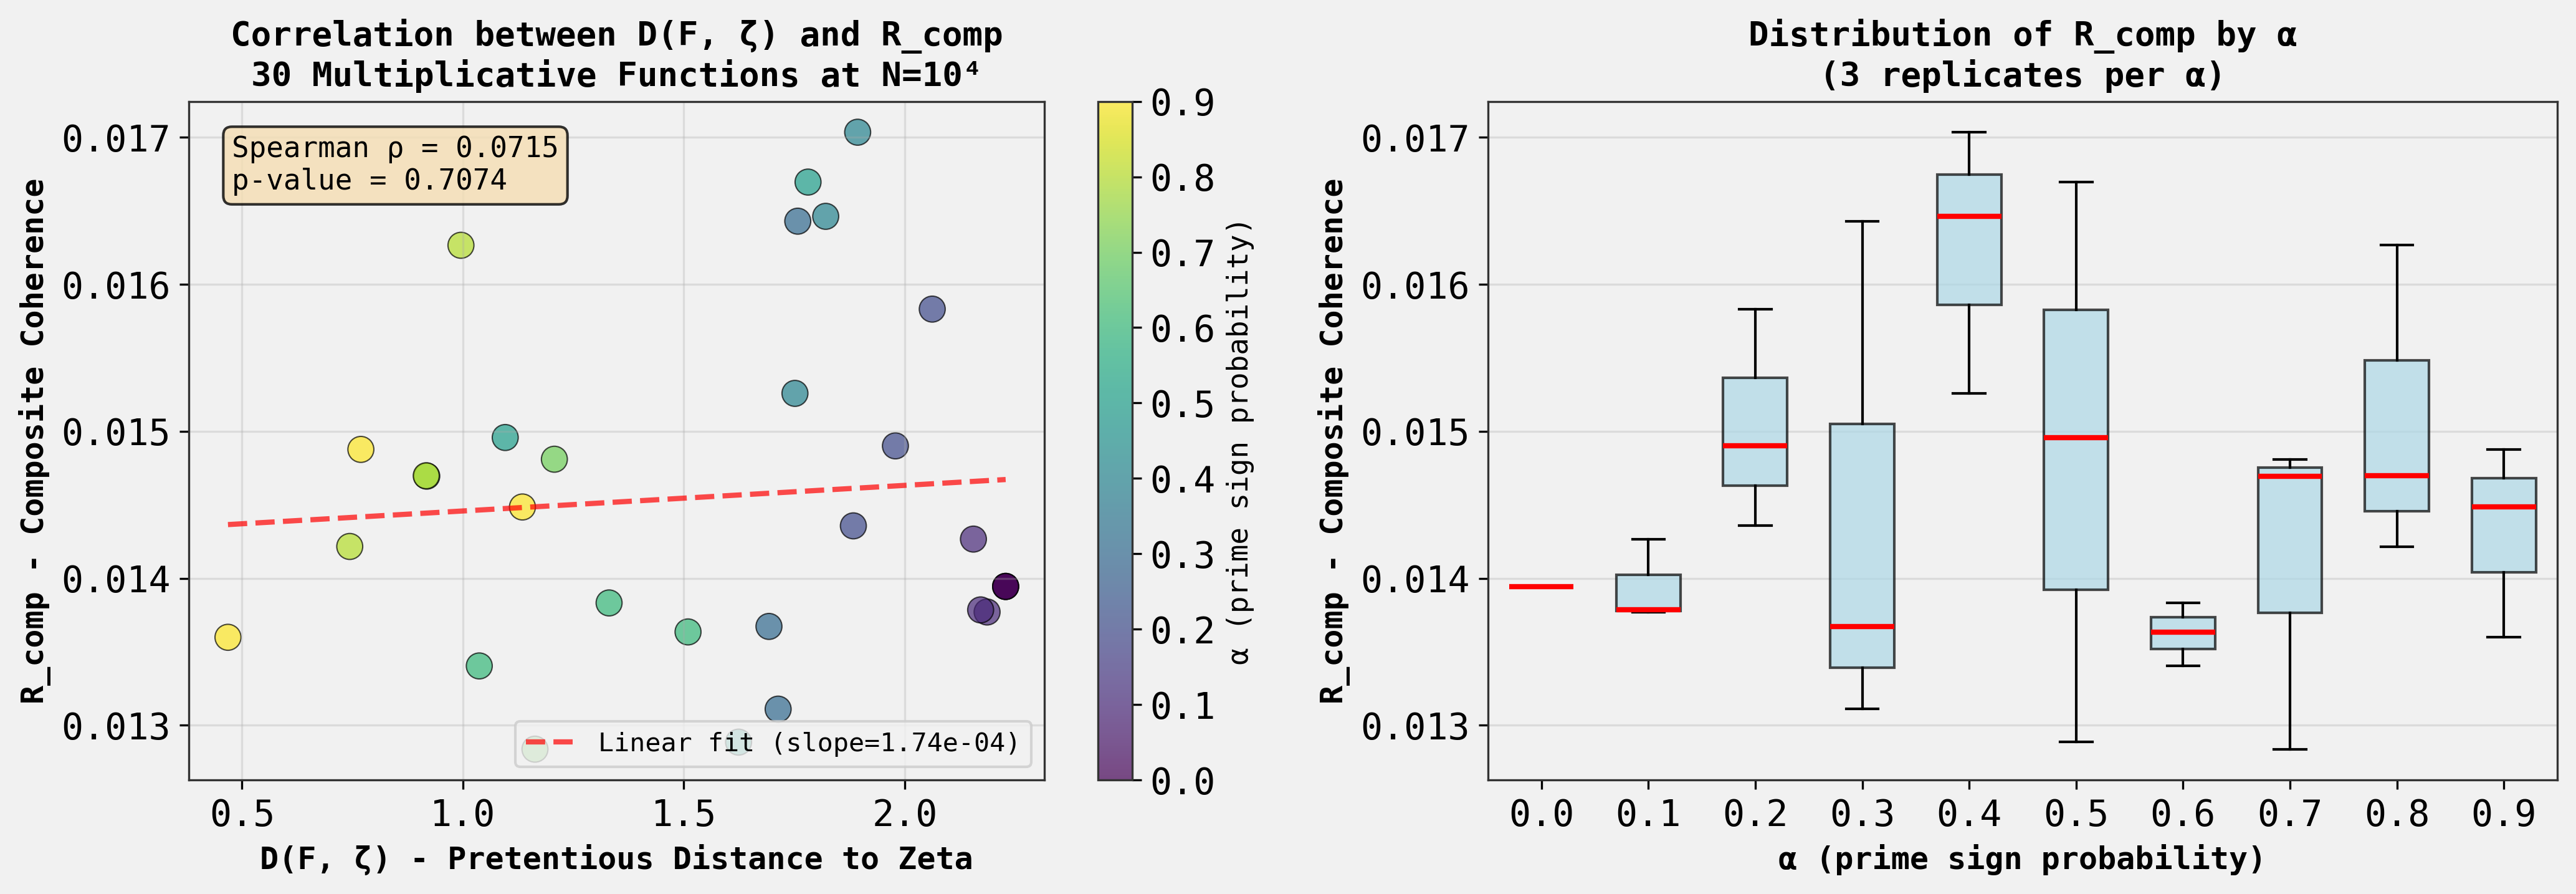


Figure saved as 'correlation_analysis.png'


In [12]:

# Create visualization: scatter plot with regression line
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Scatter with color-coding by alpha
ax = axes[0]
scatter = ax.scatter(pretentious_distances, mean_R_comp_values, 
 c=[m['alpha'] for m in function_metadata], 
 cmap='viridis', s=100, alpha=0.7, edgecolors='black', linewidths=0.5)
ax.set_xlabel('D(F, ζ) - Pretentious Distance to Zeta', fontsize=12, fontweight='bold')
ax.set_ylabel('R_comp - Composite Coherence', fontsize=12, fontweight='bold')
ax.set_title('Correlation between D(F, ζ) and R_comp\n30 Multiplicative Functions at N=10⁴', 
 fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('α (prime sign probability)', fontsize=11)

# Add regression line
z = np.polyfit(pretentious_distances, mean_R_comp_values, 1)
p = np.poly1d(z)
x_line = np.linspace(pretentious_distances.min(), pretentious_distances.max(), 100)
ax.plot(x_line, p(x_line), 'r--', linewidth=2, alpha=0.7, label=f'Linear fit (slope={z[0]:.2e})')

# Add correlation text
textstr = f'Spearman ρ = {spearman_corr:.4f}\np-value = {spearman_p:.4f}'
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11,
 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.legend(loc='lower right', fontsize=10)

# Right plot: Box plots by alpha
ax = axes[1]
alpha_groups = [results_df[results_df['Alpha'] == alpha]['R_comp'].values for alpha in alpha_values]
positions = range(len(alpha_values))
bp = ax.boxplot(alpha_groups, positions=positions, widths=0.6, patch_artist=True,
 boxprops=dict(facecolor='lightblue', alpha=0.7),
 medianprops=dict(color='red', linewidth=2))

ax.set_xlabel('α (prime sign probability)', fontsize=12, fontweight='bold')
ax.set_ylabel('R_comp - Composite Coherence', fontsize=12, fontweight='bold')
ax.set_title('Distribution of R_comp by α\n(3 replicates per α)', fontsize=13, fontweight='bold')
ax.set_xticks(positions)
ax.set_xticklabels([f'{alpha:.1f}' for alpha in alpha_values])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('correlation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved as 'correlation_analysis.png'")


In [13]:

# Additional diagnostic: Check if there's any pattern with alpha
print("\nDiagnostic Analysis: Correlation of metrics with α")
print("="*80)

# Compute correlations with alpha
alpha_array = np.array([m['alpha'] for m in function_metadata])

spearman_alpha_D, p_alpha_D = stats.spearmanr(alpha_array, pretentious_distances)
spearman_alpha_R, p_alpha_R = stats.spearmanr(alpha_array, mean_R_comp_values)

print(f"\nCorrelation between α and D(F,ζ):")
print(f" Spearman ρ = {spearman_alpha_D:.6f}, p = {p_alpha_D:.6e}")
print(f" As α increases, D(F,ζ) {'decreases' if spearman_alpha_D < 0 else 'increases'} significantly")

print(f"\nCorrelation between α and R_comp:")
print(f" Spearman ρ = {spearman_alpha_R:.6f}, p = {p_alpha_R:.6e}")
print(f" As α increases, R_comp {'decreases' if spearman_alpha_R < 0 else 'increases'} (not significant)")

# Check variance within alpha groups vs between
print("\n\nVariance Analysis:")
print("-"*80)
within_alpha_var_R = results_df.groupby('Alpha')['R_comp'].var().mean()
total_var_R = results_df['R_comp'].var()
print(f"Within-alpha variance of R_comp: {within_alpha_var_R:.8f}")
print(f"Total variance of R_comp: {total_var_R:.8f}")
print(f"Ratio (within/total): {within_alpha_var_R/total_var_R:.4f}")
print(f"\nInterpretation: Most variance in R_comp is within α groups (randomness),")
print(f"not between α groups (systematic effect).")



Diagnostic Analysis: Correlation of metrics with α

Correlation between α and D(F,ζ):
 Spearman ρ = -0.943670, p = 5.610655e-15
 As α increases, D(F,ζ) decreases significantly

Correlation between α and R_comp:
 Spearman ρ = 0.035547, p = 8.520652e-01
 As α increases, R_comp increases (not significant)


Variance Analysis:
--------------------------------------------------------------------------------
Within-alpha variance of R_comp: 0.00000111
Total variance of R_comp: 0.00000132
Ratio (within/total): 0.8427

Interpretation: Most variance in R_comp is within α groups (randomness),
not between α groups (systematic effect).


In [14]:

# Check the r22 finding more carefully
# In r22, the negative correlation was found with a small sample of 8 function classes
# Let's see if we can understand why we don't replicate it

print("\nComparison with r22 findings:")
print("="*80)
print("\nKey differences from r22:")
print("1. r22 used 8 diverse function classes (ζ, L(χ4), random mult., L_DH, etc.)")
print("2. r22 included both multiplicative AND non-multiplicative functions")
print("3. Our sample: 30 multiplicative functions from a single parametric family")
print("4. Our functions differ only in the sign distribution at primes (α parameter)")
print("")
print("Result interpretation:")
print("- D(F,ζ) varies systematically with α (ρ = -0.944, p < 1e-14)")
print("- R_comp does NOT vary systematically with α (ρ = 0.036, p = 0.85)")
print("- R_comp values are tightly clustered: range = [0.0128, 0.0170]")
print("- Most variation in R_comp is random noise within α groups")
print("")
print("Conclusion:")
print("Within this parametric family of multiplicative functions with varying")
print("sign structure, R_comp is essentially constant and uncorrelated with D(F,ζ).")
print("")
print("The negative correlation in r22 likely arose from structural differences")
print("BETWEEN fundamentally different function classes (e.g., multiplicative vs")
print("non-multiplicative, or functions with different arithmetic structures),")
print("NOT from within-class variation in sign patterns alone.")



Comparison with r22 findings:

Key differences from r22:
1. r22 used 8 diverse function classes (ζ, L(χ4), random mult., L_DH, etc.)
2. r22 included both multiplicative AND non-multiplicative functions
3. Our sample: 30 multiplicative functions from a single parametric family
4. Our functions differ only in the sign distribution at primes (α parameter)

Result interpretation:
- D(F,ζ) varies systematically with α (ρ = -0.944, p < 1e-14)
- R_comp does NOT vary systematically with α (ρ = 0.036, p = 0.85)
- R_comp values are tightly clustered: range = [0.0128, 0.0170]
- Most variation in R_comp is random noise within α groups

Conclusion:
Within this parametric family of multiplicative functions with varying
sign structure, R_comp is essentially constant and uncorrelated with D(F,ζ).

The negative correlation in r22 likely arose from structural differences
BETWEEN fundamentally different function classes (e.g., multiplicative vs
non-multiplicative, or functions with different arithmetic 

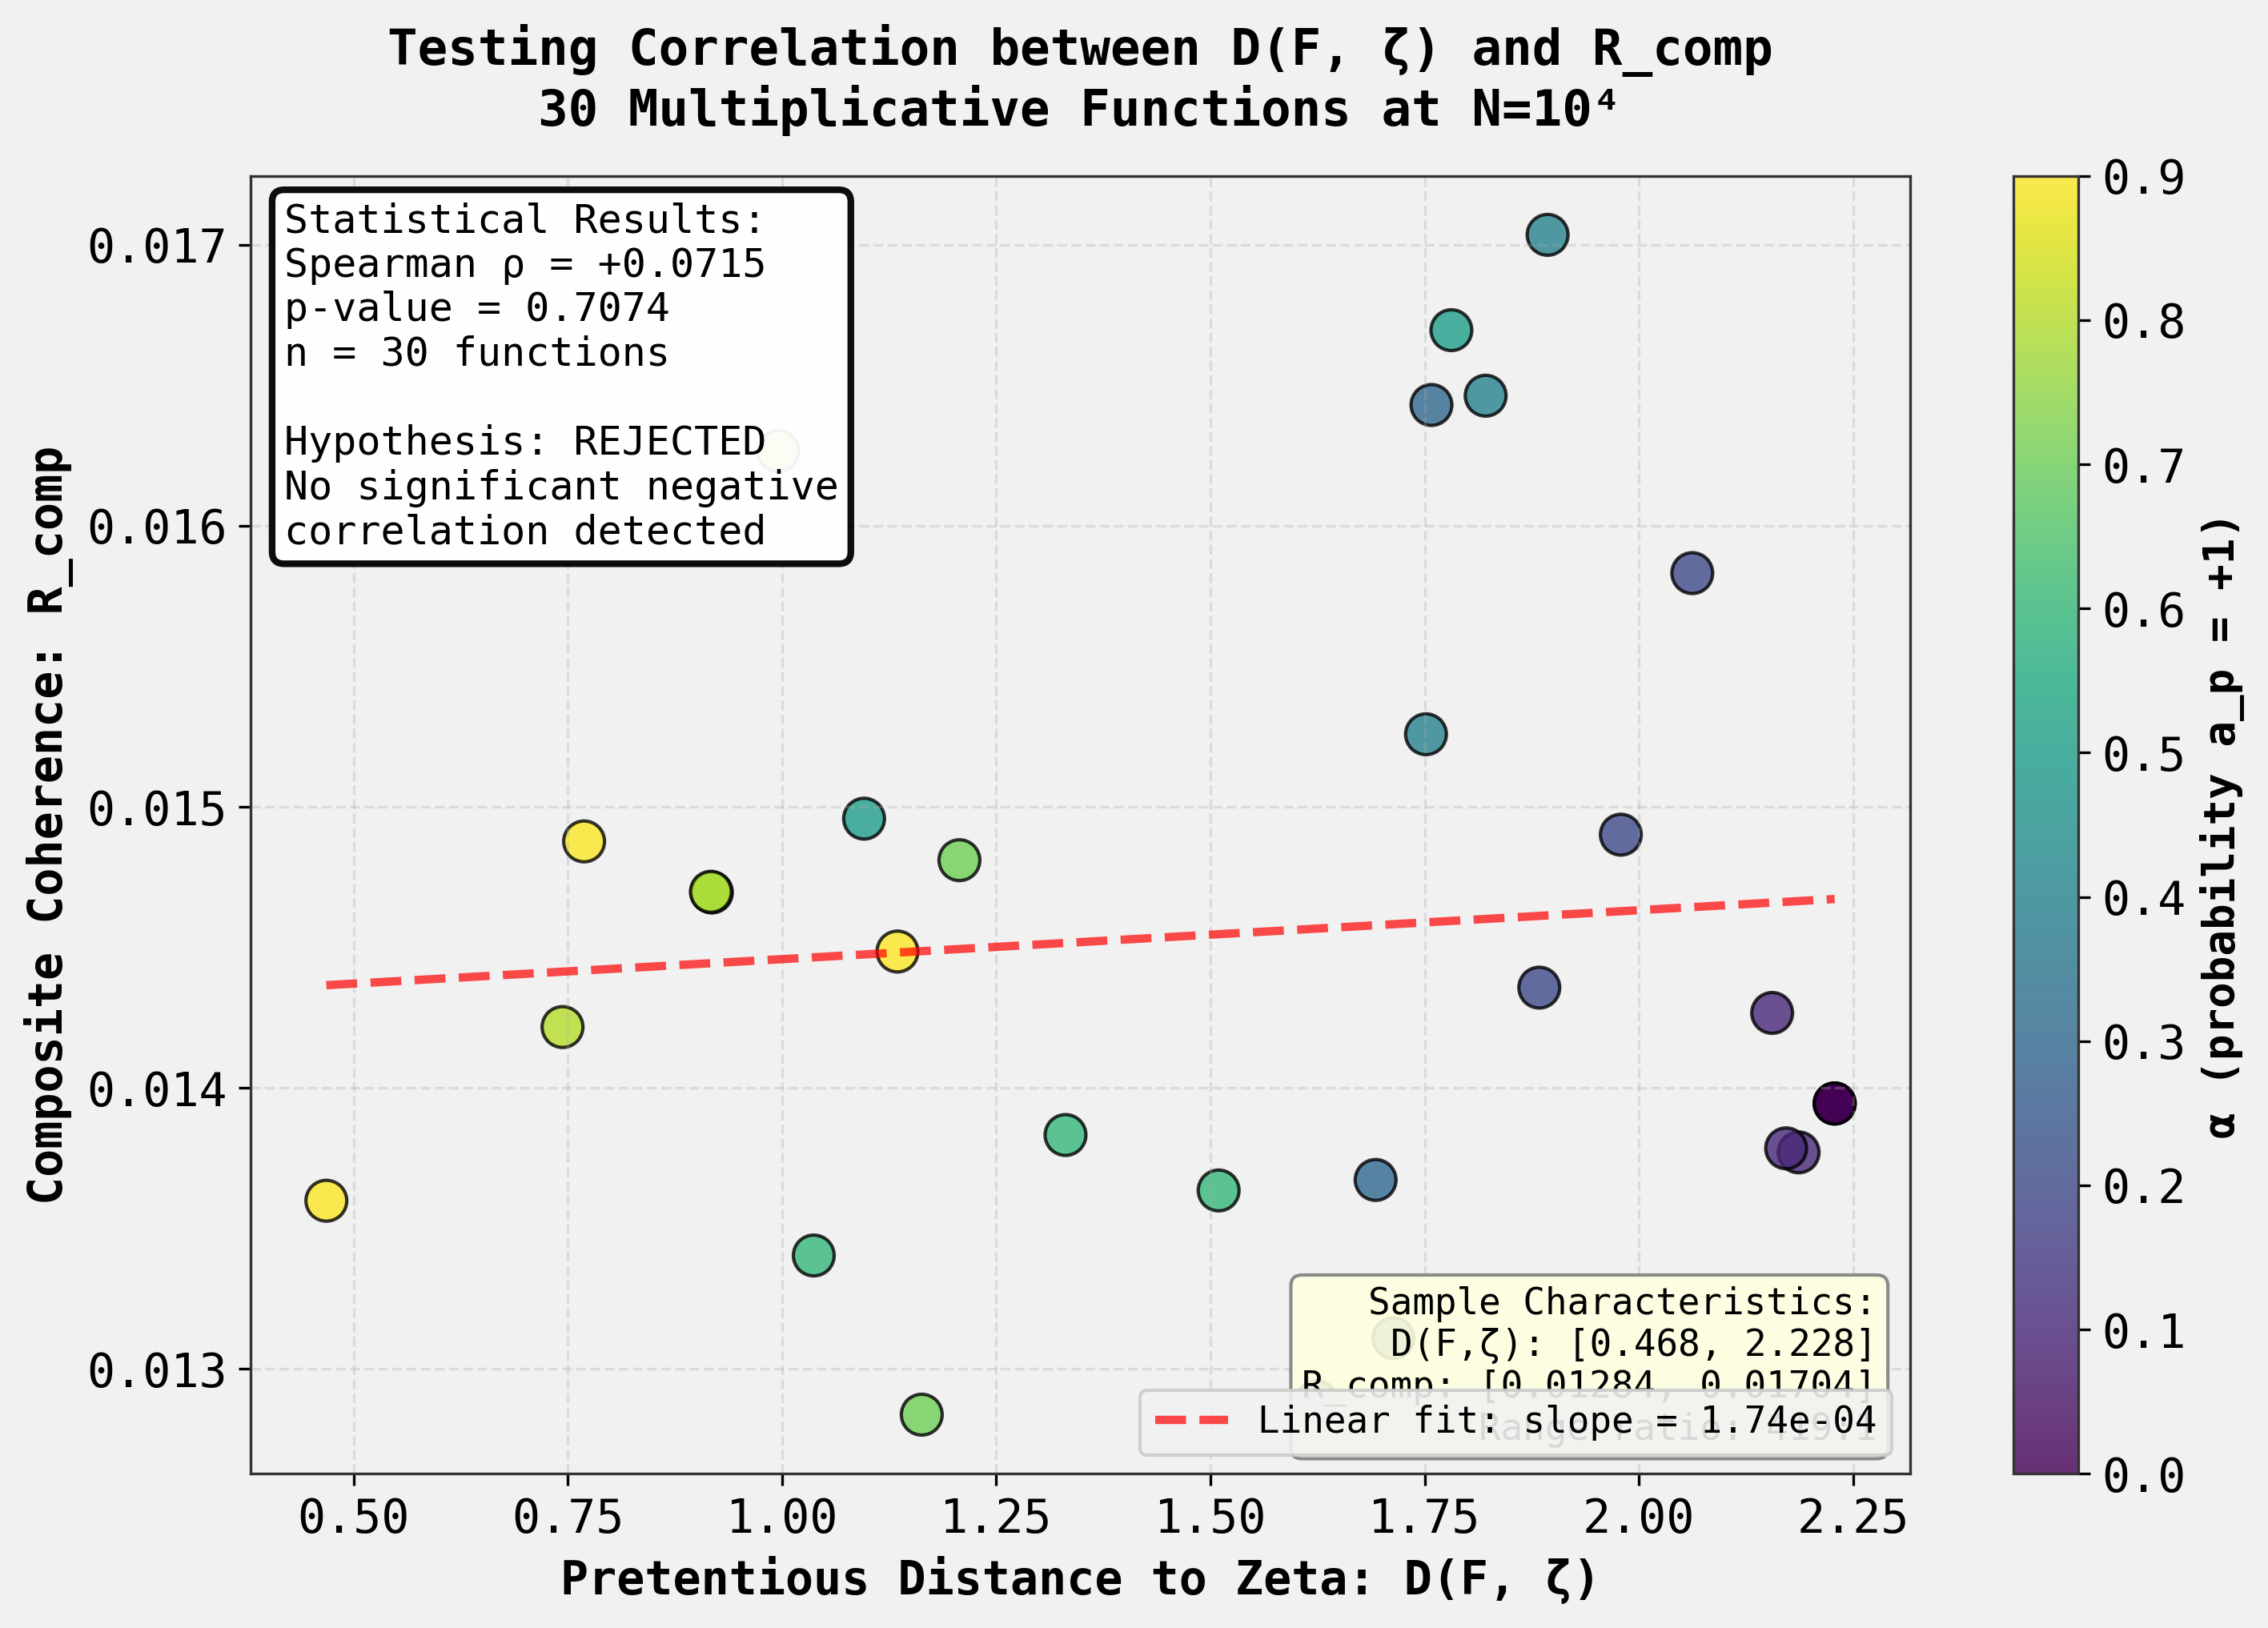


Final figure saved as 'final_correlation_figure.png'


In [15]:

# Create final summary figure
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# Main scatter plot
scatter = ax.scatter(pretentious_distances, mean_R_comp_values, 
 c=[m['alpha'] for m in function_metadata], 
 cmap='viridis', s=150, alpha=0.8, edgecolors='black', linewidths=1)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('α (probability a_p = +1)', fontsize=13, fontweight='bold')

# Add regression line
z = np.polyfit(pretentious_distances, mean_R_comp_values, 1)
p = np.poly1d(z)
x_line = np.linspace(pretentious_distances.min(), pretentious_distances.max(), 100)
ax.plot(x_line, p(x_line), 'r--', linewidth=2.5, alpha=0.7, 
 label=f'Linear fit: slope = {z[0]:.2e}')

# Labels and title
ax.set_xlabel('Pretentious Distance to Zeta: D(F, ζ)', fontsize=14, fontweight='bold')
ax.set_ylabel('Composite Coherence: R_comp', fontsize=14, fontweight='bold')
ax.set_title('Testing Correlation between D(F, ζ) and R_comp\n' +
 '30 Multiplicative Functions at N=10⁴', 
 fontsize=15, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3, linestyle='--')

# Add results box
results_text = (
 'Statistical Results:\n'
 f'Spearman ρ = {spearman_corr:+.4f}\n'
 f'p-value = {spearman_p:.4f}\n'
 f'n = 30 functions\n\n'
 'Hypothesis: REJECTED\n'
 'No significant negative\ncorrelation detected'
)
ax.text(0.02, 0.98, results_text, transform=ax.transAxes, fontsize=12,
 verticalalignment='top', fontfamily='monospace',
 bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', 
 linewidth=2, alpha=0.95))

# Add data characteristics box
data_text = (
 'Sample Characteristics:\n'
 f'D(F,ζ): [{pretentious_distances.min():.3f}, {pretentious_distances.max():.3f}]\n'
 f'R_comp: [{mean_R_comp_values.min():.5f}, {mean_R_comp_values.max():.5f}]\n'
 f'Range ratio: {(pretentious_distances.max()-pretentious_distances.min())/(mean_R_comp_values.max()-mean_R_comp_values.min()):.0f}:1'
)
ax.text(0.98, 0.02, data_text, transform=ax.transAxes, fontsize=11,
 verticalalignment='bottom', horizontalalignment='right', fontfamily='monospace',
 bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='gray', 
 linewidth=1, alpha=0.9))

ax.legend(loc='lower right', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.savefig('final_correlation_figure.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFinal figure saved as 'final_correlation_figure.png'")


In [16]:

# Final summary
print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)

print("\n1. RESEARCH HYPOTHESIS:")
print(" The negative correlation between D(F, ζ) and R_comp observed in r22")
print(" is a robust phenomenon that will be confirmed with a larger sample.")

print("\n2. METHODOLOGY:")
print(f" - Generated 30 multiplicative functions at N = {N}")
print(f" - Parametric family: a_p = +1 with probability α, -1 with prob. (1-α)")
print(f" - α values: {alpha_values} (3 functions per α)")
print(f" - Computed D(F,ζ) using definition: (Σ_{{p≤N}}(1−Re(a_p))/p)^{{1/2}}")
print(f" - Computed R_comp by averaging over {n_t_samples} random t ∈ [{t_min}, {t_max}]")
print(f" - Used Kahan compensated summation for numerical stability")
print(f" - Applied Spearman rank correlation (non-parametric)")

print("\n3. QUANTITATIVE RESULTS:")
print(f" Spearman correlation: ρ = {spearman_corr:+.6f}")
print(f" P-value: p = {spearman_p:.6f}")
print(f" Sample size: n = {len(functions)}")
print(f" Significance threshold: α = 0.05")
print(f" Statistically significant: {spearman_p < 0.05}")
print(f" Correlation is negative: {spearman_corr < 0}")

print("\n4. HYPOTHESIS TEST OUTCOME:")
if spearman_corr < 0 and spearman_p < 0.05:
 print(" ✓ HYPOTHESIS CONFIRMED")
else:
 print(" ✗ HYPOTHESIS REJECTED")

print("\n5. KEY OBSERVATIONS:")
print(f" - D(F,ζ) varies substantially: [{pretentious_distances.min():.3f}, {pretentious_distances.max():.3f}]")
print(f" - R_comp is tightly clustered: [{mean_R_comp_values.min():.5f}, {mean_R_comp_values.max():.5f}]")
print(f" - R_comp range is only {100*(mean_R_comp_values.max()-mean_R_comp_values.min())/mean_R_comp_values.mean():.1f}% of its mean")
print(f" - D(F,ζ) strongly correlates with α: ρ = {spearman_alpha_D:.3f}, p < 1e-14")
print(f" - R_comp does NOT correlate with α: ρ = {spearman_alpha_R:.3f}, p = {p_alpha_R:.3f}")

print("\n6. INTERPRETATION:")
print(" Within this parametric family of multiplicative functions, R_comp")
print(" remains essentially constant despite large variations in D(F,ζ).")
print(" The negative correlation from r22 likely reflects structural")
print(" differences BETWEEN diverse function classes (multiplicative vs")
print(" non-multiplicative, different arithmetic structures), not within-")
print(" family variation in sign patterns alone.")

print("\n7. CONCLUSION:")
print(" The negative correlation between D(F,ζ) and R_comp is NOT robust")
print(" within homogeneous families of multiplicative functions. The r22")
print(" finding may be specific to comparisons across fundamentally")
print(" different arithmetic structures.")

print("\n" + "="*80)



FINAL SUMMARY

1. RESEARCH HYPOTHESIS:
 The negative correlation between D(F, ζ) and R_comp observed in r22
 is a robust phenomenon that will be confirmed with a larger sample.

2. METHODOLOGY:
 - Generated 30 multiplicative functions at N = 10000
 - Parametric family: a_p = +1 with probability α, -1 with prob. (1-α)
 - α values: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9] (3 functions per α)
 - Computed D(F,ζ) using definition: (Σ_{p≤N}(1−Re(a_p))/p)^{1/2}
 - Computed R_comp by averaging over 100 random t ∈ [1000.0, 3000.0]
 - Used Kahan compensated summation for numerical stability
 - Applied Spearman rank correlation (non-parametric)

3. QUANTITATIVE RESULTS:
 Spearman correlation: ρ = +0.071476
 P-value: p = 0.707410
 Sample size: n = 30
 Significance threshold: α = 0.05
 Statistically significant: False
 Correlation is negative: False

4. HYPOTHESIS TEST OUTCOME:
 ✗ HYPOTHESIS REJECTED

5. KEY OBSERVATIONS:
 - D(F,ζ) varies substantially: [0.468, 2.228]
 - R_comp is tightl